# CaMKII system analysis

In [1]:
using ModelingToolkit
using OrdinaryDiffEq, SteadyStateDiffEq, DiffEqCallbacks
using Plots
using LsqFit
using CaMKIIModel
using CaMKIIModel: μM, hil, second, Hz
Plots.default(lw=1.5)

## CaMKII sensitivity to calcium
Model CaM/Calcium binding only. No phosphorylation or oxidation.

In [2]:
@parameters Ca = 0μM ROS = 0μM
sys = get_camkii_sys(Ca; ROS, simplify=true)

Model camkii_sys:
Equations (17):
  17 standard: see equations(camkii_sys)
Unknowns (17): see unknowns(camkii_sys)
  Ca2CaM_C(t) [defaults to 0.08433]
  Ca2CaM_N(t) [defaults to 0.008578]
  Ca4CaM(t) [defaults to 2.0e-5]
  CaM0_CaMK(t) [defaults to 1]
  ⋮
Parameters (44): see parameters(camkii_sys)
  kCaM0_on [defaults to 3.8e-6]
  kCaM0_off [defaults to 0.0055]
  kCaM4P_on [defaults to 0]
  kCaM2NP_off [defaults to 0.000333333]
  ⋮
Observed (3): see observed(camkii_sys)

In [3]:
prob = SteadyStateProblem(sys, [sys.k_phosCaM => 0])
alg = DynamicSS(Rodas5P())

ca = exp10.(range(log10(0.03μM), log10(10μM), 1001))
prob_func = (prob, i, repeat) -> begin
    remake(prob, p=[Ca => ca[i]])
end
trajectories = length(ca)
sol0 = solve(prob, alg; abstol=1e-10, reltol=1e-10) ## warmup
sim = solve(EnsembleProblem(prob; prob_func, safetycopy=false), alg; trajectories, abstol=1e-10, reltol=1e-10)

EnsembleSolution Solution of length 1001 with uType:
SciMLBase.NonlinearSolution{Float64, 1, Vector{Float64}, Vector{Float64}, SciMLBase.SteadyStateProblem{Vector{Float64}, true, ModelingToolkit.MTKParameters{Vector{Float64}, Vector{Float64}, Tuple{}, Tuple{}, Tuple{}, Tuple{}}, SciMLBase.ODEFunction{true, SciMLBase.AutoSpecialize, ModelingToolkit.GeneratedFunctionWrapper{(2, 3, true), RuntimeGeneratedFunctions.RuntimeGeneratedFunction{(:__mtk_arg_1, :___mtkparameters___, :t), ModelingToolkit.var"#_RGF_ModTag", ModelingToolkit.var"#_RGF_ModTag", (0x57e65267, 0x0da70c6f, 0xa1146a00, 0x48f08f41, 0xc064fda9), Nothing}, RuntimeGeneratedFunctions.RuntimeGeneratedFunction{(:ˍ₋out, :__mtk_arg_1, :___mtkparameters___, :t), ModelingToolkit.var"#_RGF_ModTag", ModelingToolkit.var"#_RGF_ModTag", (0xcd706e2f, 0x88a68fe7, 0x2a5f60f5, 0xd960013d, 0x1e3f7725), Nothing}}, LinearAlgebra.UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothin

In [4]:
"""Extract values from ensemble simulations by a symbol"""
extract(sim, k) = map(s -> s[k], sim)
"""Calculate Root Mean Square Error (RMSE)"""
rmse(fit) = sqrt(sum(abs2, fit.resid) / length(fit.resid))

Main.var"##230".rmse

Components

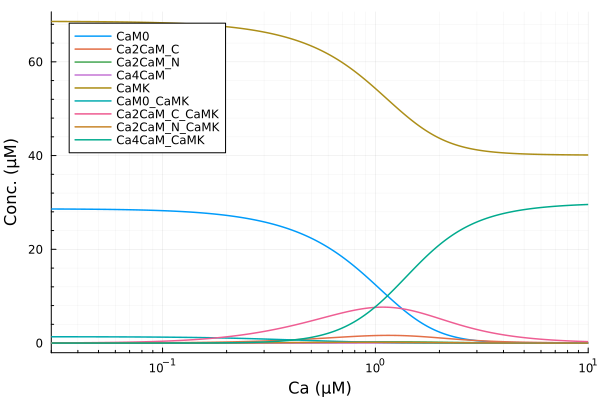

In [5]:
xopts = (xlabel="Ca (μM)", xscale=:log10, minorgrid=true, xlims=(ca[1], ca[end]))
plot(ca, extract(sim, sys.CaM0), lab="CaM0", ylabel="Conc. (μM)"; xopts...)
plot!(ca, extract(sim, sys.Ca2CaM_C), lab="Ca2CaM_C")
plot!(ca, extract(sim, sys.Ca2CaM_N), lab="Ca2CaM_N")
plot!(ca, extract(sim, sys.Ca4CaM), lab="Ca4CaM")
plot!(ca, extract(sim, sys.CaMK), lab="CaMK")
plot!(ca, extract(sim, sys.CaM0_CaMK), lab="CaM0_CaMK")
plot!(ca, extract(sim, sys.Ca2CaM_C_CaMK), lab="Ca2CaM_C_CaMK")
plot!(ca, extract(sim, sys.Ca2CaM_N_CaMK), lab="Ca2CaM_N_CaMK")
plot!(ca, extract(sim, sys.Ca4CaM_CaMK), lab="Ca4CaM_CaMK", legend=:topleft)

We excluded CaM0_CaMK (bound but lost all calcium) from the active CaMKII fraction

Basal activity without ca is 4.7190264362839685e-8


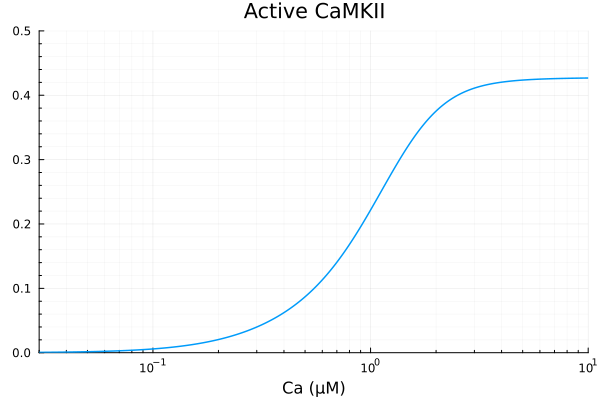

In [6]:
CaMKAct = 1 - (sys.CaMK + sys.CaM0_CaMK) / sys.CAMKII_T
println("Basal activity without ca is ", sol0[CaMKAct][end])
xdata = ca
ydata = extract(sim, CaMKAct)
plot(xdata, ydata, label=false, title="Active CaMKII", ylims=(0, 0.5); xopts...)

## Least-square fitting of steady state CaMKII activity

In [7]:
@. model_camk(x, p) = p[1] * hil(x, p[2], p[4]) + p[3]
p0 = [0.4, 1μM, 0.0, 2.0]
lb = [0.0, 0.001μM, 0.0, 1.0]
fit = curve_fit(model_camk, xdata, ydata, p0; lower=lb, autodiff=:forwarddiff)

LsqFit.LsqFitResult{Vector{Float64}, Vector{Float64}, Matrix{Float64}, Vector{Float64}, Vector{LsqFit.LMState{LsqFit.LevenbergMarquardt}}}([0.42985864901855403, 0.9629481840627955, 0.005187220691454256, 2.2985815431214025], [0.004766880016269715, 0.004762305827564668, 0.004757683251840647, 0.004753011581095032, 0.004748290553895919, 0.004743519511493798, 0.004738697910478312, 0.004733825405363892, 0.004728901435690406, 0.004723925357757465  …  0.006155558529901961, 0.006173872671347169, 0.006192167337247534, 0.006210317422071565, 0.006228218522397688, 0.00624551299057019, 0.006262963129796406, 0.006280201254696083, 0.006297177846306401, 0.006313695586499135], [0.00034441293217246996 -0.0003532746817559725 1.0 -0.0005133754019680895; 0.00034904103038528583 -0.0003580202034696147 1.0 -0.0005194002591627495; … ; 0.9953494635010501 -0.004749646742822832 1.0 0.004645196337508179; 0.9954108653036408 -0.004687225502245434 1.0 0.0045955548008200005], true, Iter     Function value   Gradient no

Parameters

In [8]:
pestim = coef(fit)

4-element Vector{Float64}:
 0.42985864901855403
 0.9629481840627955
 0.005187220691454256
 2.2985815431214025

In [9]:
println("Basal activity: ", pestim[3])
println("Maximal activated activity: ", pestim[1])
println("Half-saturation Ca concentration: ", pestim[2], " μM")
println("Hill coefficient: ", pestim[4])
println("RMSE: ", rmse(fit))

Basal activity: 0.005187220691454256
Maximal activated activity: 0.42985864901855403
Half-saturation Ca concentration: 0.9629481840627955 μM
Hill coefficient: 2.2985815431214025
RMSE: 0.004825704888897066


Fit result and the original model

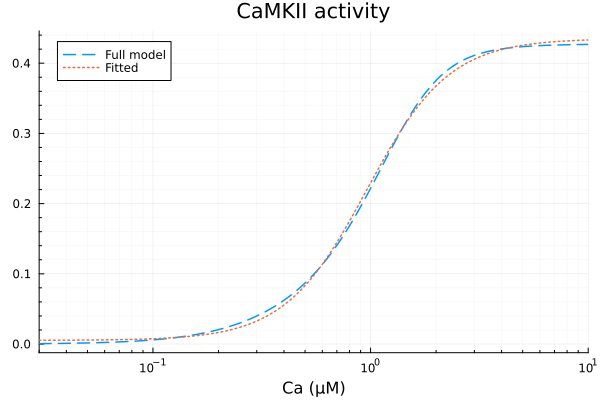

In [10]:
yestim = model_camk.(xdata, Ref(pestim))

p1 = plot(xdata, [ydata yestim], lab=["Full model" "Fitted"], line=[:dash :dot], title="CaMKII activity", legend=:topleft; xopts...)

## The simplified CaMKII system

In [11]:
simpsys = CaMKIIModel.get_camkii_simp_sys(Ca; ROS, simplify=true)

Model camkii_sys:
Equations (8):
  8 standard: see equations(camkii_sys)
Unknowns (8): see unknowns(camkii_sys)
  CaMKB(t) [defaults to 0.008728]
  CaMKBOX(t) [defaults to 0]
  CaMKP(t) [defaults to 0.003916]
  CaMKPOX(t) [defaults to 0]
  ⋮
Parameters (14): see parameters(camkii_sys)
  nCa_CaMK [defaults to 2.293]
  k_P2_P1 [defaults to 6.66667e-5]
  krd_CaMK [defaults to 2.22222e-5]
  kox_CaMK [defaults to 0.000291]
  ⋮
Observed (2): see observed(camkii_sys)

## Comparing original and simplified model

In [12]:
sys = build_neonatal_ecc_sys(simplify=true, reduce_iso=true)
sys_simp = build_neonatal_ecc_sys(simplify=true, reduce_iso=true, reduce_camk=true)

println("# of state variable in the original model: ", length(unknowns(sys)))
println("# of state variable in the simplified model: ", length(unknowns(sys_simp)))

# of state variable in the original model: 84
# of state variable in the simplified model: 75


In [13]:
tend = 500.0second
stimstart = 100.0second
stimend = 300.0second
alg = KenCarp47()
@unpack Istim = sys
callback = build_stim_callbacks(Istim, stimend; period=1second, starttime=stimstart)
prob = ODEProblem(sys, [], tend);
prob_simp = ODEProblem(sys_simp, [sys_simp.kphos_CaMK => 5Hz], tend);

  9.885484 seconds (24.27 M allocations: 1.118 GiB, 2.76% gc time, 77.40% compilation time)
  7.482301 seconds (16.50 M allocations: 761.318 MiB, 3.23% gc time, 67.93% compilation time)


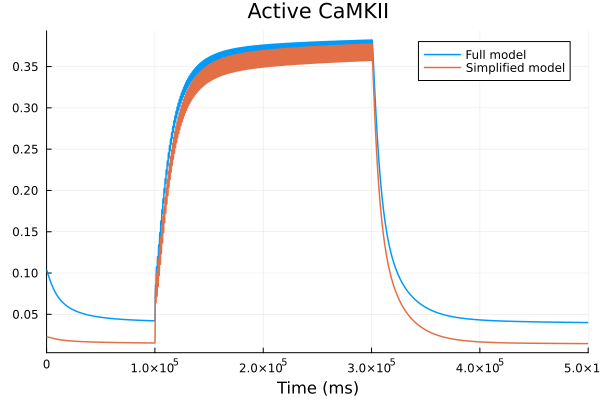

In [14]:
@time sol = solve(prob, alg; callback)
@time sol_simp = solve(prob_simp, alg; callback)

plot(sol, idxs=sys.CaMKAct, label="Full model", title="Active CaMKII")
plot!(sol_simp, idxs=sys_simp.CaMKAct, label="Simplified model", xlabel="Time (ms)")

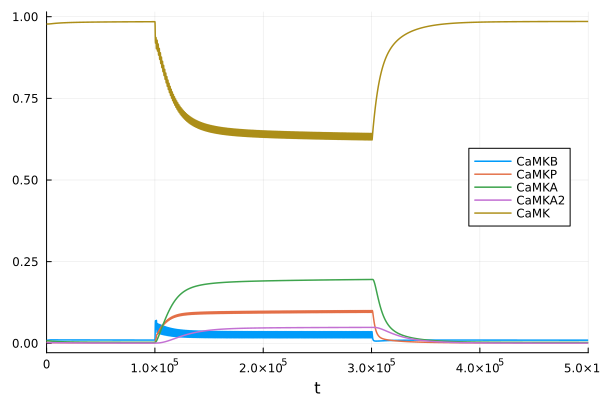

In [15]:
@unpack CaMKB, CaMKP, CaMKA, CaMKA2, CaMK = sys_simp
plot(sol_simp, idxs=[CaMKB, CaMKP, CaMKA, CaMKA2, CaMK], legend=:right)

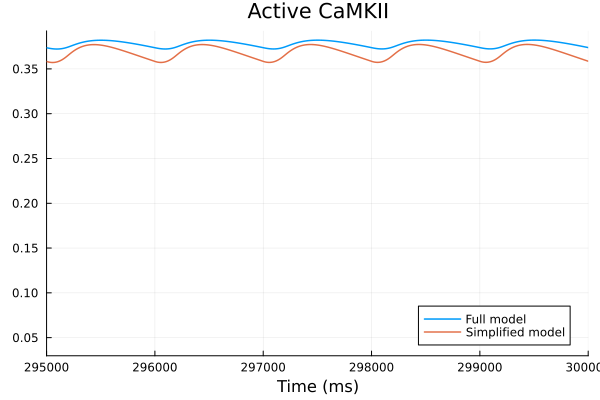

In [16]:
plot(sol, idxs=sys.CaMKAct, label="Full model", title="Active CaMKII")
plot!(sol_simp, idxs=sys_simp.CaMKAct, label="Simplified model", xlabel="Time (ms)", tspan=(295second, 300.0second))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*